# TI IWR6843 Fall Detection — 2D Spatial-Temporal CNN Training

This notebook trains a PyTorch **2D Spatial-Temporal Convolutional Neural Network (`Radar4DCNN`)** on the preprocessed **TI IWR6843** feature tensors.

### Model Architecture (`Radar4DCNN`)
```
Input Feature Tensor: (Batch Size, 4 Channels, 10 Frames, 64 Points)
  ├── Conv Block 1: Conv2D(4 -> 32, kernel=(3,5)) + BatchNorm + ReLU + MaxPool2d(1,2)
  ├── Conv Block 2: Conv2D(32 -> 64, kernel=(3,5)) + BatchNorm + ReLU + MaxPool2d(2,2)
  ├── Conv Block 3: Conv2D(64 -> 128, kernel=(3,3)) + BatchNorm + ReLU + AdaptiveAvgPool2d(1,1)
  ├── Flatten (128 Features) + Dropout (p=0.4)
  ├── Linear (128 -> 64) + ReLU
  └── Output Linear (64 -> 2 Classes): [0 = Non-Fall ADL, 1 = Fall]
```

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

# Dynamic path resolution
preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../../datasets/preprocessed")

X = np.load(preproc_dir / "X_ti_clean_balanced.npy")
y = np.load(preproc_dir / "y_ti_clean_balanced.npy")

print(f"Loaded TI IWR6843 Feature Tensor: {X.shape}")
print(f"Target Labels: {np.bincount(y.astype(int))} (0 = ADL, 1 = Fall)")

Loaded TI IWR6843 Feature Tensor: (728, 10, 32, 4)
Target Labels: [364 364] (0 = ADL, 1 = Fall)


In [2]:
# PyTorch Train/Test Split (80% Train, 20% Test)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Reshape to (Batch, 4 Channels, 10 Frames, 64 Points)
X_tr_t = torch.tensor(X_tr, dtype=torch.float32).permute(0, 3, 1, 2)
X_te_t = torch.tensor(X_te, dtype=torch.float32).permute(0, 3, 1, 2)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_te_t = torch.tensor(y_te, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=32, shuffle=False)
print(f"Train size: {len(X_tr_t)} | Test size: {len(X_te_t)}")

Train size: 582 | Test size: 146


In [3]:
class Radar4DCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2):
        super(Radar4DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((1, 2)),
            nn.Conv2d(32, 64, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        feat = self.features(x).view(x.size(0), -1)
        return self.classifier(feat)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Radar4DCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [4]:
# Train Model with Best Validation Checkpointing
models_dir = Path("models")
if not models_dir.exists(): models_dir = Path("../models")
if not models_dir.exists(): models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)
best_model_path = models_dir / "cnn_ti_best.pth"

epochs = 20
losses, accs = [], []
best_val_loss = float('inf')

for ep in range(epochs):
    model.train()
    total_loss, correct = 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * bx.size(0)
        correct += (out.argmax(1) == by).sum().item()
    train_loss = total_loss / len(X_tr_t)
    train_acc = correct / len(X_tr_t)
    losses.append(train_loss)
    accs.append(train_acc)

   # Validation step
    model.eval()
    val_loss, val_corr = 0.0, 0
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            loss = criterion(out, by)
            val_loss += loss.item() * bx.size(0)
            val_corr += (out.argmax(1) == by).sum().item()
    val_loss /= len(X_te_t)
    val_acc = val_corr / len(X_te_t)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        saved_flag = " [BEST SAVED]"
    else:
        saved_flag = ""

    if (ep + 1) % 5 == 0 or ep == 0 or saved_flag:
        print(f"Epoch {ep+1:02d}/{epochs} - Tr Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%{saved_flag}")

# Reload best model weights for evaluation
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"\nLoaded best model checkpoint from: {best_model_path} (Best Val Loss: {best_val_loss:.4f})")

Epoch 01/20 - Tr Loss: 0.5024 Acc: 76.12% | Val Loss: 0.9422 Acc: 53.42% [BEST SAVED]


Epoch 04/20 - Tr Loss: 0.0562 Acc: 97.77% | Val Loss: 0.3515 Acc: 85.62% [BEST SAVED]


Epoch 05/20 - Tr Loss: 0.0194 Acc: 99.66% | Val Loss: 0.5538 Acc: 80.82%


Epoch 08/20 - Tr Loss: 0.0662 Acc: 96.74% | Val Loss: 0.1014 Acc: 95.89% [BEST SAVED]


Epoch 10/20 - Tr Loss: 0.0239 Acc: 99.48% | Val Loss: 0.3785 Acc: 86.30%


...

Epoch 13/20 - Tr Loss: 0.0011 Acc: 100.00% | Val Loss: 0.0183 Acc: 98.63% [BEST SAVED]


Epoch 15/20 - Tr Loss: 0.0020 Acc: 100.00% | Val Loss: 0.0351 Acc: 98.63%


Epoch 16/20 - Tr Loss: 0.0013 Acc: 100.00% | Val Loss: 0.0160 Acc: 98.63% [BEST SAVED]


Epoch 17/20 - Tr Loss: 0.0016 Acc: 100.00% | Val Loss: 0.0077 Acc: 100.00% [BEST SAVED]


Epoch 20/20 - Tr Loss: 0.0199 Acc: 99.48% | Val Loss: 6.4670 Acc: 52.05%

Loaded best model checkpoint from: ..\models\cnn_ti_best.pth (Best Val Loss: 0.0077)


Test Accuracy: 100.00% | Test ROC-AUC: 1.0000

Classification Report:
                  precision    recall  f1-score   support

 ADL (Non-Fall)       1.00      1.00      1.00        73
           Fall       1.00      1.00      1.00        73

       accuracy                           1.00       146
      macro avg       1.00      1.00      1.00       146
   weighted avg       1.00      1.00      1.00       146



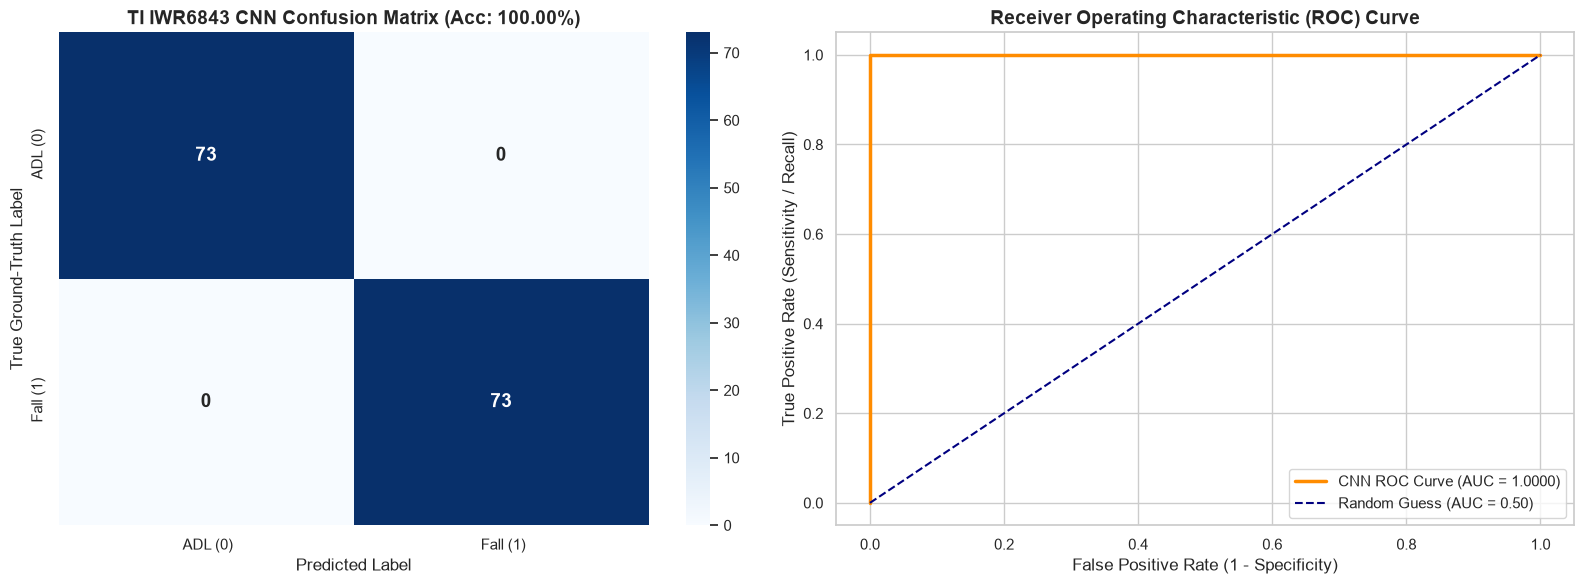

In [5]:
# Evaluate Model
model.eval()
preds, probs, targets = [], [], []
with torch.no_grad():
    for bx, by in test_loader:
        bx = bx.to(device)
        out = model(bx)
        probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
        preds.extend(out.argmax(1).cpu().numpy())
        targets.extend(by.numpy())

targets = np.array(targets)
preds = np.array(preds)
probs = np.array(probs)

acc = accuracy_score(targets, preds)
auc = roc_auc_score(targets, probs)
cm = confusion_matrix(targets, preds)
fpr, tpr, _ = roc_curve(targets, probs)

print(f"Test Accuracy: {acc*100:.2f}% | Test ROC-AUC: {auc:.4f}")
print("\nClassification Report:\n", classification_report(targets, preds, target_names=[" ADL (Non-Fall)", " Fall"]))

# Visual Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=[" ADL (0)", " Fall (1)"],
            yticklabels=[" ADL (0)", " Fall (1)"],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title(f"TI IWR6843 CNN Confusion Matrix (Acc: {acc*100:.2f}%)", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Ground-Truth Label", fontsize=12)

# ROC Curve
axes[1].plot(fpr, tpr, color="darkorange", linewidth=2.5, label=f"CNN ROC Curve (AUC = {auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--", linewidth=1.5, label="Random Guess (AUC = 0.50)")
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve", fontweight="bold", fontsize=14)
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
axes[1].set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
axes[1].legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()
